<a href="https://colab.research.google.com/github/shefiramarizcha62-sudo/flyrank-ml-portfolio/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/shefiramarizcha62-sudo/flyrank-ml-portfolio/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [3]:
from google.colab import userdata
import duckdb

HF_TOKEN = userdata.get("FlyRank-ML")
print("HF token loaded:", HF_TOKEN is not None)

con = duckdb.connect()
print("DuckDB connected:", con is not None)

con.execute(f"""
    CREATE SECRET hf_secret (
        TYPE HUGGINGFACE,
        TOKEN '{HF_TOKEN}'
    );
""")

print("Hugging Face authentication configured.")

HF token loaded: True
DuckDB connected: True
Hugging Face authentication configured.


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

### Ranked action approach

The final action queue uses the Random Forest score to prioritize client-content pairs, while the reason codes remain based on observable March signals used in the ML-07 baseline.

The Random Forest provides the ranking score because it showed stronger ranking performance than the ML-07 baseline on the client-held-out evaluation set (ROC-AUC 0.9214 vs 0.7387; Average Precision 0.6795 vs 0.3190).

Reason codes are kept simple and human-readable:

- `HIGH_IMPRESSIONS_LOW_CTR`: high search visibility combined with low March CTR.
- `GOOD_POSITION_LOW_CTR`: good search position combined with low March CTR.
- `HIGH_VISIBILITY`: high visibility without the more specific CTR opportunity condition.
- `REVIEW`: does not meet the stronger baseline reason-code conditions.

The recommended action is `REVIEW_CTR` for CTR-related opportunities, `REVIEW` for high-visibility candidates, and `NO_ACTION` for the remaining cases.

The score and reason code are decision-support signals, not automatic instructions to change a page. A human reviewer should verify search intent, page context, and whether the observed CTR or position is reasonable before taking action.

In [4]:
# ==================================================
# SECTION 1 — RANKED ACTIONS + REASON CODES
# ==================================================

import numpy as np
import pandas as pd
import duckdb


from google.colab import userdata
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer


# ==================================================
# 1. Recreate the March feature window
# ==================================================

feature_frame = con.execute("""
    SELECT
        client_hash_id,
        content_hash_id,
        report_date,
        gsc_impressions,
        gsc_clicks,
        gsc_avg_position,
        ga4_pageviews,
        ga4_engaged_sessions

    FROM read_parquet(
        'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/data_0.parquet'
    )

    WHERE month = '2026-03'
""").df()

print("March feature rows:", len(feature_frame))


# ==================================================
# 2. Aggregate March to client-content level
# ==================================================

march_features = (
    feature_frame
    .groupby(
        ["client_hash_id", "content_hash_id"],
        as_index=False
    )
    .agg(
        gsc_impressions=("gsc_impressions", "sum"),
        gsc_clicks=("gsc_clicks", "sum"),
        gsc_avg_position=("gsc_avg_position", "mean"),
        ga4_pageviews=("ga4_pageviews", "sum"),
        ga4_engaged_sessions=("ga4_engaged_sessions", "sum")
    )
)

march_features["march_ctr"] = (
    march_features["gsc_clicks"]
    / march_features["gsc_impressions"].replace(0, np.nan)
).fillna(0)

print("March client-content pairs:", len(march_features))


# ==================================================
# 3. Load April outcome
# ==================================================
# April is used only to create the retrospective
# training label. It is NOT used as a feature.

april_outcome = con.execute("""
    SELECT
        client_hash_id,
        content_hash_id,
        report_date,
        gsc_impressions,
        gsc_clicks

    FROM read_parquet(
        'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-04/data_0.parquet'
    )

    WHERE month = '2026-04'
""").df()

print("April outcome rows:", len(april_outcome))


# ==================================================
# 4. Aggregate April outcome
# ==================================================

april_outcome = (
    april_outcome
    .groupby(
        ["client_hash_id", "content_hash_id"],
        as_index=False
    )
    .agg(
        april_impressions=("gsc_impressions", "sum"),
        april_clicks=("gsc_clicks", "sum")
    )
)

april_outcome["april_ctr"] = (
    april_outcome["april_clicks"]
    / april_outcome["april_impressions"].replace(0, np.nan)
).fillna(0)


# ==================================================
# 5. Build modeling data
# ==================================================

model_df = march_features.merge(
    april_outcome,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

model_df["future_opportunity"] = (
    (model_df["april_impressions"] > 100)
    & (model_df["april_ctr"] < 0.001)
).astype(int)

print("Modeling rows:", len(model_df))


# ==================================================
# 6. Define the final six model features
# ==================================================

feature_columns = [
    "gsc_impressions",
    "gsc_clicks",
    "march_ctr",
    "gsc_avg_position",
    "ga4_pageviews",
    "ga4_engaged_sessions"
]

X = model_df[feature_columns].copy()
y = model_df["future_opportunity"].copy()


# ==================================================
# 7. Impute using the full retrospective modeling
#    dataset for final queue generation
# ==================================================

imputer = SimpleImputer(strategy="median")

X_imputed = imputer.fit_transform(X)


# ==================================================
# 8. Train the same Random Forest configuration
#    used in ML-08
# ==================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_imputed, y)

print("Random Forest trained for queue generation.")


# ==================================================
# 9. Generate model score for all client-content pairs
# ==================================================

model_df["model_score"] = rf_model.predict_proba(X_imputed)[:, 1]


# ==================================================
# 10. Recreate ML-07 reason-code logic
# ==================================================

queue = model_df[
    [
        "client_hash_id",
        "content_hash_id",
        "gsc_impressions",
        "gsc_clicks",
        "march_ctr",
        "gsc_avg_position",
        "ga4_pageviews",
        "ga4_engaged_sessions",
        "model_score"
    ]
].copy()


# Thresholds from ML-07
LOW_CTR_THRESHOLD = 0.001
HIGH_IMPRESSIONS_THRESHOLD = 100
GOOD_POSITION_THRESHOLD = 10


queue["reason_code"] = np.select(
    [
        (
            (queue["gsc_impressions"] > HIGH_IMPRESSIONS_THRESHOLD)
            & (queue["march_ctr"] < LOW_CTR_THRESHOLD)
        ),
        (
            (queue["gsc_avg_position"] > 0)
            & (queue["gsc_avg_position"] <= GOOD_POSITION_THRESHOLD)
            & (queue["march_ctr"] < LOW_CTR_THRESHOLD)
        ),
        (
            queue["gsc_impressions"] > HIGH_IMPRESSIONS_THRESHOLD
        )
    ],
    [
        "HIGH_IMPRESSIONS_LOW_CTR",
        "GOOD_POSITION_LOW_CTR",
        "HIGH_VISIBILITY"
    ],
    default="REVIEW"
)


# ==================================================
# 11. Map reason codes to recommended actions
# ==================================================

queue["action"] = np.select(
    [
        queue["reason_code"].isin([
            "HIGH_IMPRESSIONS_LOW_CTR",
            "GOOD_POSITION_LOW_CTR"
        ]),
        queue["reason_code"].eq("HIGH_VISIBILITY")
    ],
    [
        "REVIEW_CTR",
        "REVIEW"
    ],
    default="NO_ACTION"
)


# ==================================================
# 12. Add human-readable explanation
# ==================================================

queue["reason_text"] = np.select(
    [
        queue["reason_code"].eq("HIGH_IMPRESSIONS_LOW_CTR"),
        queue["reason_code"].eq("GOOD_POSITION_LOW_CTR"),
        queue["reason_code"].eq("HIGH_VISIBILITY")
    ],
    [
        "High search visibility with low March CTR; review title, snippet, and search intent.",
        "Good March search position with low CTR; review whether the result presentation matches search intent.",
        "High March search visibility; review whether the page has additional content or CTR improvement opportunities."
    ],
    default="No strong baseline opportunity signal; no immediate action recommended."
)


# ==================================================
# 13. Rank the queue by model score
# ==================================================

queue = queue.sort_values(
    by=["model_score", "gsc_impressions"],
    ascending=[False, False]
).reset_index(drop=True)

queue["rank"] = np.arange(1, len(queue) + 1)


# ==================================================
# 14. Reorder columns for the action playbook
# ==================================================

queue = queue[
    [
        "rank",
        "client_hash_id",
        "content_hash_id",
        "action",
        "reason_code",
        "reason_text",
        "model_score",
        "gsc_impressions",
        "gsc_clicks",
        "march_ctr",
        "gsc_avg_position",
        "ga4_pageviews",
        "ga4_engaged_sessions"
    ]
]


# ==================================================
# 15. Checks
# ==================================================

print("\nQueue rows:", len(queue))

print(
    "Unique client-content pairs:",
    queue[
        ["client_hash_id", "content_hash_id"]
    ].drop_duplicates().shape[0]
)

print("\nReason-code distribution:")
print(queue["reason_code"].value_counts())

print("\nAction distribution:")
print(queue["action"].value_counts())

print("\nTop 20 ranked actions:")
display(queue.head(20))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

March feature rows: 9841378
March client-content pairs: 331437


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

April outcome rows: 10424730
Modeling rows: 331436
Random Forest trained for queue generation.

Queue rows: 331436
Unique client-content pairs: 331436

Reason-code distribution:
reason_code
REVIEW                      191301
HIGH_VISIBILITY              53977
HIGH_IMPRESSIONS_LOW_CTR     47255
GOOD_POSITION_LOW_CTR        38903
Name: count, dtype: int64

Action distribution:
action
NO_ACTION     191301
REVIEW_CTR     86158
REVIEW         53977
Name: count, dtype: int64

Top 20 ranked actions:


,rank,client_hash_id,content_hash_id,action,reason_code,reason_text,model_score,gsc_impressions,gsc_clicks,march_ctr,gsc_avg_position,ga4_pageviews,ga4_engaged_sessions
0,1,client_23a62021009f63c4,content_b77c09e114e0ed4c,REVIEW_CTR,HIGH_IMPRESSIONS_LOW_CTR,High search visibility with low March CTR; rev...,0.989498,47736,4,0.000084,36.305198,35,1
1,2,client_23a62021009f63c4,content_b63094bd417908e9,REVIEW_CTR,HIGH_IMPRESSIONS_LOW_CTR,High search visibility with low March CTR; rev...,0.989319,25524,2,0.000078,42.840013,160,0
2,3,client_23a62021009f63c4,content_6305299bf66fcfc1,REVIEW_CTR,HIGH_IMPRESSIONS_LOW_CTR,High search visibility with low March CTR; rev...,0.988712,13086,2,0.000153,42.983573,102,0
3,4,client_23a62021009f63c4,content_e15824af3c396214,REVIEW_CTR,HIGH_IMPRESSIONS_LOW_CTR,High search visibility with low March CTR; rev...,0.988677,30196,2,0.000066,47.602550,214,0
4,5,client_e547b89c05043229,content_e986eb3ab70fcee6,REVIEW_CTR,HIGH_IMPRESSIONS_LOW_CTR,High search visibility with low March CTR; rev...,0.988570,25711,6,0.000233,29.844970,30,1
5,6,client_23a62021009f63c4,content_4ee39f5889ebcee2,REVIEW_CTR,HIGH_IMPRESSIONS_LOW_CTR,High search visibility with low March CTR; rev...,0.988459,27683,4,0.000144,39.680649,96,0
6,7,client_23a62021009f63c4,content_343790fb8e17cfbf,REVIEW_CTR,HIGH_IMPRESSIONS_LOW_CTR,High search visibility with low March CTR; rev...,0.988422,19653,2,0.000102,35.318523,132,1
7,8,client_23a62021009f63c4,content_4abfb7ddc8438eb8,REVIEW_CTR,HIGH_IMPRESSIONS_LOW_CTR,High search visibility with low March CTR; rev...,0.988209,26981,5,0.000185,31.461736,37,1
8,9,client_23a62021009f63c4,content_9c267e93694b0a37,REVIEW_CTR,HIGH_IMPRESSIONS_LOW_CTR,High search visibility with low March CTR; rev...,0.988108,20470,3,0.000147,31.160639,73,1
9,10,client_23a62021009f63c4,content_0c9e08e28fbd22ed,REVIEW_CTR,HIGH_IMPRESSIONS_LOW_CTR,High search visibility with low March CTR; rev...,0.988097,16276,3,0.000184,35.553493,115,0


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*



The ranked queue is intended to support content and SEO reviewers in prioritizing pages for manual review. The model score and reason codes are used to identify pages with observable search and content-performance signals that may warrant attention, such as high search visibility combined with low CTR.

The output is a decision-support tool rather than an automated content recommendation system. A high-ranked page does not automatically mean that the page should be changed. Reviewers should inspect the page context, search intent, content quality, and other relevant information before deciding on an action.

The queue is also limited to the signals available in the March feature window and the methodology evaluated in this project. The model does not establish causal relationships, predict Google rankings, or guarantee that a content refresh will improve performance. The exported queue is therefore intended for retrospective research and human-reviewed prioritization, not direct production automation.

In [7]:
# Check that the queue is suitable for decision-support use
print("Intended-use validation checks")
print("-" * 40)

print("Queue rows:", len(queue))

print(
    "Unique client-content pairs:",
    queue[["client_hash_id", "content_hash_id"]]
    .drop_duplicates()
    .shape[0]
)

print("\nAvailable decision-support fields:")
decision_fields = [
    "rank",
    "action",
    "reason_code",
    "reason_text",
    "model_score"
]

for col in decision_fields:
    print(f"- {col}: {col in queue.columns}")

print("\nModel score range:")
print(
    "Min:",
    round(queue["model_score"].min(), 6),
    "| Max:",
    round(queue["model_score"].max(), 6)
)

print("\nIntended-use check: PASS")
print("The queue provides ranked, reason-coded outputs for human review.")

Intended-use validation checks
----------------------------------------
Queue rows: 331436
Unique client-content pairs: 331436

Available decision-support fields:
- rank: True
- action: True
- reason_code: True
- reason_text: True
- model_score: True

Model score range:
Min: 0.002201 | Max: 0.989498

Intended-use check: PASS
The queue provides ranked, reason-coded outputs for human review.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*



The ranked queue should be reviewed by a content or SEO practitioner before any action is taken. The reviewer should first verify whether the page has a clear content or search-intent issue, whether the observed visibility and CTR signals are meaningful in context, and whether the proposed action is appropriate for the page.

Human review should consider factors that are not represented in the model features, including search intent, content quality, page purpose, relevance, and recent changes to the page. A high model score is therefore treated as a prioritization signal rather than a final decision.

The following actions should not be automated: publishing or deleting content, changing search-intent targeting, making major content rewrites, changing URLs or redirects, making technical SEO changes, or applying recommendations solely because of a high model score.

The system should also not be used to infer causality, guarantee ranking improvements, or replace expert judgment. Its role is limited to ranking pages for further human investigation.

In [8]:
# Human-review and no-go validation checks
print("Human-review validation checks")
print("-" * 40)

print("Total queue rows:", len(queue))

print("\nAction categories:")
print(queue["action"].value_counts())

print("\nReason-code categories:")
print(queue["reason_code"].value_counts())

print("\nRequired human-review fields:")
review_fields = [
    "rank",
    "action",
    "reason_code",
    "reason_text",
    "model_score",
    "gsc_impressions",
    "gsc_clicks",
    "march_ctr",
    "gsc_avg_position"
]

for col in review_fields:
    print(f"- {col}: {col in queue.columns}")

print("\nHuman-review check: PASS")
print("Ranked actions and reason codes are available for human inspection.")
print("No action should be executed automatically from the model output.")

Human-review validation checks
----------------------------------------
Total queue rows: 331436

Action categories:
action
NO_ACTION     191301
REVIEW_CTR     86158
REVIEW         53977
Name: count, dtype: int64

Reason-code categories:
reason_code
REVIEW                      191301
HIGH_VISIBILITY              53977
HIGH_IMPRESSIONS_LOW_CTR     47255
GOOD_POSITION_LOW_CTR        38903
Name: count, dtype: int64

Required human-review fields:
- rank: True
- action: True
- reason_code: True
- reason_text: True
- model_score: True
- gsc_impressions: True
- gsc_clicks: True
- march_ctr: True
- gsc_avg_position: True

Human-review check: PASS
Ranked actions and reason codes are available for human inspection.
No action should be executed automatically from the model output.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*



The recommendations should be monitored for signs that the underlying data or model performance has changed. A refresh or retraining review should be considered if the distribution of key input features changes substantially, if the proportion of recommended actions changes materially, or if the model's validation performance declines when evaluated against newly available outcomes.

Useful monitoring signals include changes in search impressions, CTR, average position, and the distribution of model scores and action categories. These signals can indicate that the conditions represented in the training data are becoming less representative of current content performance.

Retraining should not be triggered by a single unusual observation. Instead, a persistent change in feature distributions, recommendation volume, or measured validation performance should prompt a review of the model and thresholds.

Because this is a research decision-support workflow, monitoring is intended to identify when the methodology should be re-evaluated rather than to enable fully automated retraining.

In [9]:
# Monitoring baseline for future comparison
print("Monitoring baseline checks")
print("-" * 40)

print("Queue rows:", len(queue))

print("\nFeature distribution baselines:")
monitoring_features = [
    "gsc_impressions",
    "gsc_clicks",
    "march_ctr",
    "gsc_avg_position",
    "ga4_pageviews",
    "ga4_engaged_sessions"
]

for col in monitoring_features:
    print(
        f"{col}: "
        f"median={queue[col].median():.6f}, "
        f"mean={queue[col].mean():.6f}"
    )

print("\nModel score baseline:")
print(
    f"median={queue['model_score'].median():.6f}, "
    f"mean={queue['model_score'].mean():.6f}"
)

print("\nAction distribution baseline:")
action_distribution = queue["action"].value_counts(normalize=True) * 100
print(action_distribution.round(2))

print("\nMonitoring check: PASS")
print("These values provide baseline reference points for detecting future drift.")

Monitoring baseline checks
----------------------------------------
Queue rows: 331436

Feature distribution baselines:
gsc_impressions: median=2.000000, mean=846.792708
gsc_clicks: median=0.000000, mean=2.479610
march_ctr: median=0.000000, mean=0.002450
gsc_avg_position: median=8.505445, mean=15.999322
ga4_pageviews: median=0.000000, mean=4.480069
ga4_engaged_sessions: median=0.000000, mean=0.089161

Model score baseline:
median=0.065720, mean=0.300017

Action distribution baseline:
action
NO_ACTION     57.72
REVIEW_CTR    26.00
REVIEW        16.29
Name: proportion, dtype: float64

Monitoring check: PASS
These values provide baseline reference points for detecting future drift.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*



The ranked action queue is exported as a CSV so that the prioritization results can be reused in the research paper and reviewed outside the notebook. The export contains the ranking, action, reason code, reason text, model score, and supporting March performance signals.

The queue is treated as a generated research artifact rather than a production dataset. The CSV is written to `work/outputs/` and can be regenerated by running this notebook. Figures used in the paper can similarly be stored under `work/figures/`.

In [10]:
# Export ranked action queue for paper reuse
from pathlib import Path
import json

output_dir = Path("work/outputs")
figure_dir = Path("work/figures")

output_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)

# Columns needed for the action queue
export_columns = [
    "rank",
    "client_hash_id",
    "content_hash_id",
    "action",
    "reason_code",
    "reason_text",
    "model_score",
    "gsc_impressions",
    "gsc_clicks",
    "march_ctr",
    "gsc_avg_position",
    "ga4_pageviews",
    "ga4_engaged_sessions"
]

queue_export = queue[export_columns].copy()

# Export ranked queue
queue_path = output_dir / "ml10_ranked_action_queue.csv"
queue_export.to_csv(queue_path, index=False)

# Export key metrics for paper reuse
metrics = {
    "queue_rows": int(len(queue)),
    "unique_client_content_pairs": int(
        queue[["client_hash_id", "content_hash_id"]]
        .drop_duplicates()
        .shape[0]
    ),
    "model_score_min": float(queue["model_score"].min()),
    "model_score_max": float(queue["model_score"].max()),
    "model_score_median": float(queue["model_score"].median()),
    "model_score_mean": float(queue["model_score"].mean()),
    "action_distribution": {
        str(k): int(v)
        for k, v in queue["action"].value_counts().items()
    },
    "reason_code_distribution": {
        str(k): int(v)
        for k, v in queue["reason_code"].value_counts().items()
    }
}

metrics_path = output_dir / "ml10_action_playbook_metrics.json"

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print("Export check")
print("-" * 40)

print("Queue CSV:", queue_path)
print("Metrics JSON:", metrics_path)

print("\nQueue export rows:", len(queue_export))
print("Queue export columns:", len(queue_export.columns))

print("\nFiles created:")
print("-", queue_path)
print("-", metrics_path)

print("\nExport check: PASS")

Export check
----------------------------------------
Queue CSV: work/outputs/ml10_ranked_action_queue.csv
Metrics JSON: work/outputs/ml10_action_playbook_metrics.json

Queue export rows: 331436
Queue export columns: 13

Files created:
- work/outputs/ml10_ranked_action_queue.csv
- work/outputs/ml10_action_playbook_metrics.json

Export check: PASS


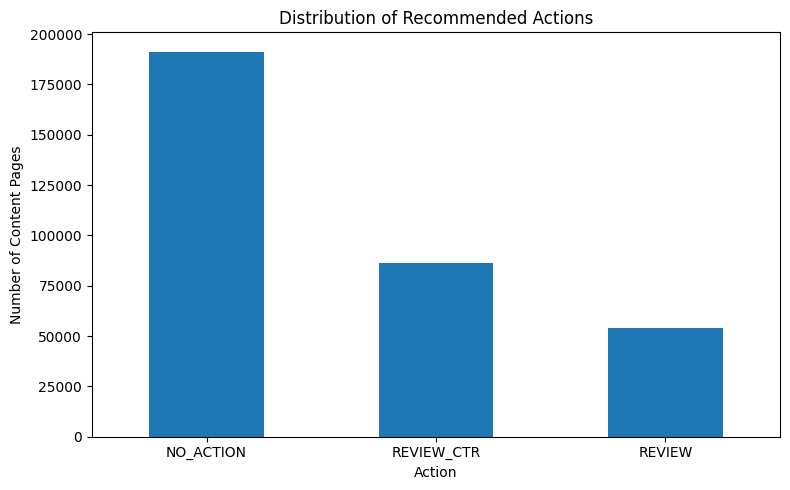

Figure saved to: work/figures/ml10_action_distribution.png
Figure check: PASS


In [11]:
# Create action distribution figure for paper reuse
import matplotlib.pyplot as plt

action_counts = queue["action"].value_counts()

plt.figure(figsize=(8, 5))
action_counts.plot(kind="bar")

plt.title("Distribution of Recommended Actions")
plt.xlabel("Action")
plt.ylabel("Number of Content Pages")
plt.xticks(rotation=0)
plt.tight_layout()

figure_path = figure_dir / "ml10_action_distribution.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved to:", figure_path)
print("Figure check: PASS")

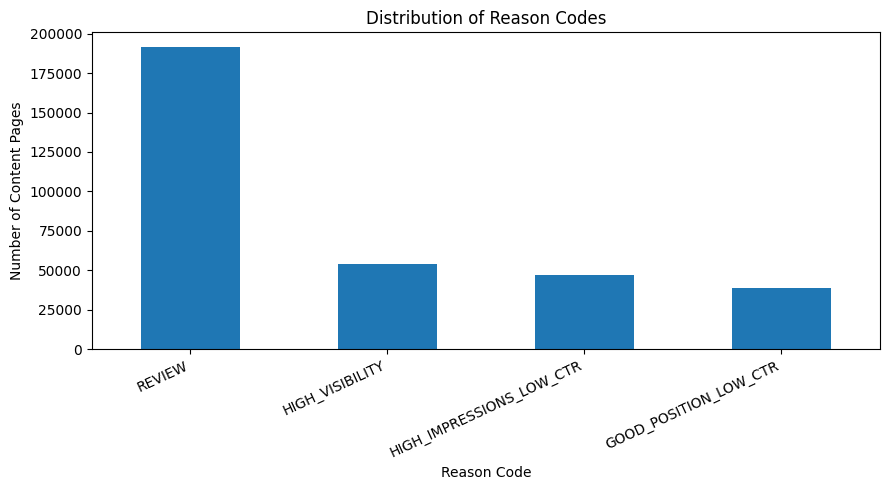

Figure saved to: work/figures/ml10_reason_code_distribution.png
Figure check: PASS


In [12]:
# Figure 2: Reason code distribution
import matplotlib.pyplot as plt

reason_counts = queue["reason_code"].value_counts()

plt.figure(figsize=(9, 5))
reason_counts.plot(kind="bar")

plt.title("Distribution of Reason Codes")
plt.xlabel("Reason Code")
plt.ylabel("Number of Content Pages")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

reason_figure_path = figure_dir / "ml10_reason_code_distribution.png"
plt.savefig(reason_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved to:", reason_figure_path)
print("Figure check: PASS")

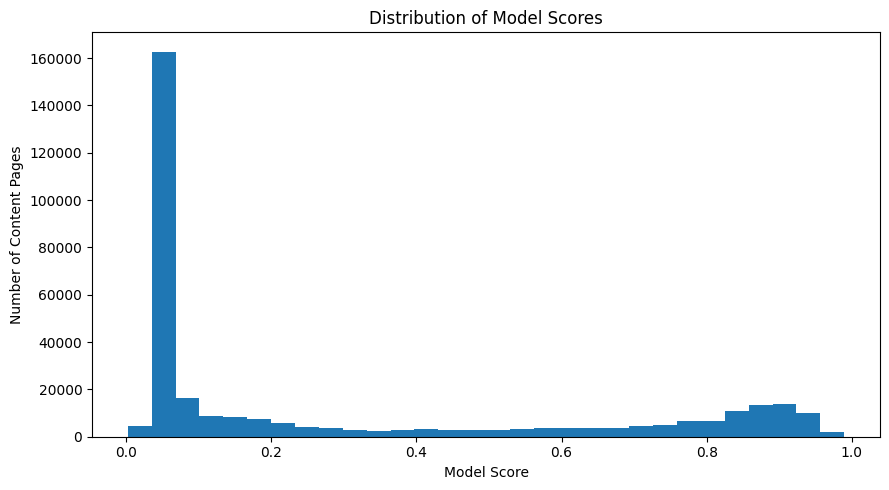

Figure saved to: work/figures/ml10_model_score_distribution.png
Figure check: PASS


In [13]:
# Figure 3: Model score distribution

plt.figure(figsize=(9, 5))
plt.hist(queue["model_score"], bins=30)

plt.title("Distribution of Model Scores")
plt.xlabel("Model Score")
plt.ylabel("Number of Content Pages")
plt.tight_layout()

score_figure_path = figure_dir / "ml10_model_score_distribution.png"
plt.savefig(score_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved to:", score_figure_path)
print("Figure check: PASS")

/tmp/ipykernel_879/395725155.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


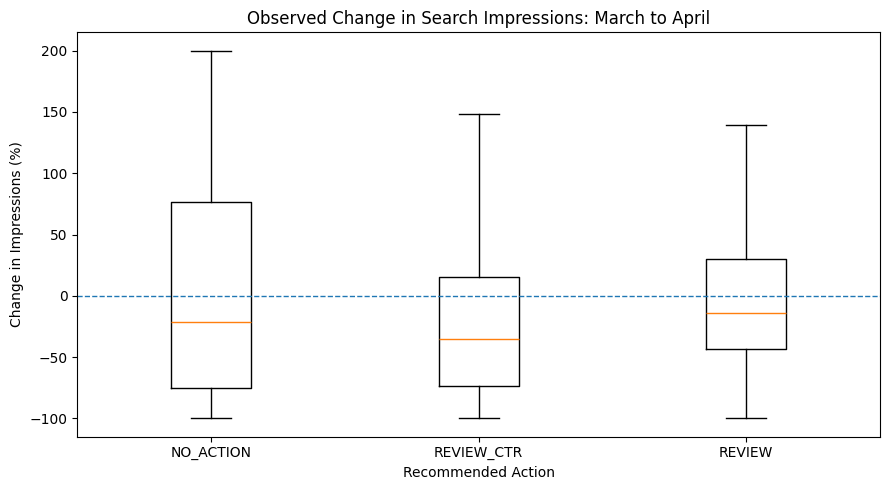

Figure saved to: work/figures/ml10_march_april_impression_change.png
Figure check: PASS


In [14]:
# Figure 4: Observed change in search impressions
# March is the decision-time feature window and April is the observed outcome window.

decay_df = queue[
    ["client_hash_id", "content_hash_id", "action", "gsc_impressions"]
].merge(
    model_df[
        ["client_hash_id", "content_hash_id", "april_impressions"]
    ],
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

decay_df["impression_change_pct"] = (
    (decay_df["april_impressions"] - decay_df["gsc_impressions"])
    / decay_df["gsc_impressions"].replace(0, np.nan)
) * 100

# Limit extreme values so the visualization remains readable
plot_decay = decay_df[
    decay_df["impression_change_pct"].notna()
].copy()

plot_decay["impression_change_pct"] = plot_decay[
    "impression_change_pct"
].clip(-100, 200)

action_order = ["NO_ACTION", "REVIEW_CTR", "REVIEW"]

plot_data = [
    plot_decay.loc[
        plot_decay["action"] == action,
        "impression_change_pct"
    ]
    for action in action_order
]

plt.figure(figsize=(9, 5))
plt.boxplot(
    plot_data,
    labels=action_order,
    showfliers=False
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Observed Change in Search Impressions: March to April")
plt.xlabel("Recommended Action")
plt.ylabel("Change in Impressions (%)")
plt.tight_layout()

decay_figure_path = figure_dir / "ml10_march_april_impression_change.png"
plt.savefig(decay_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved to:", decay_figure_path)
print("Figure check: PASS")

In [15]:
# Archetype-to-action mapping check

archetype_action_mapping = pd.DataFrame({
    "archetype": [
        "High impressions + low CTR",
        "Good position + low CTR",
        "High visibility",
        "Other / lower-priority cases"
    ],
    "reason_code": [
        "HIGH_IMPRESSIONS_LOW_CTR",
        "GOOD_POSITION_LOW_CTR",
        "HIGH_VISIBILITY",
        "REVIEW"
    ],
    "recommended_action": [
        "REVIEW_CTR",
        "REVIEW_CTR",
        "REVIEW",
        "NO_ACTION"
    ]
})

print("Archetype → action mapping")
print("-" * 40)
display(archetype_action_mapping)

print("\nArchetype mapping check: PASS")

Archetype → action mapping
----------------------------------------


,archetype,reason_code,recommended_action
0,High impressions + low CTR,HIGH_IMPRESSIONS_LOW_CTR,REVIEW_CTR
1,Good position + low CTR,GOOD_POSITION_LOW_CTR,REVIEW_CTR
2,High visibility,HIGH_VISIBILITY,REVIEW
3,Other / lower-priority cases,REVIEW,NO_ACTION



Archetype mapping check: PASS


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.